# From BST Traversal to Wikipedia Graph Explorer

This notebook is basically the **starting point** of our project, and it builds directly on what we did in Homework 3 for DSAN5500. The goal here is to show how our Binary Search Tree (BST) code evolves into a polymorphic Wikipedia scraper and explorer.

## Our Motivation

In Homework Q3.1–Q3.2, we implemented:

* A `BinarySearchTree` using linked `BSTNode`s
* A `ThingContainer` setup (`Stack`, `Queue`) to control ordering
* A `NodeProcessor` that traverses the tree depending on whether we use a stack or queue

While working on this, we realized:
**the loop inside `NodeProcessor.iterate_over()` is basically the same as the loop in `WikiExplorer.explore()`.**

The only real difference is how we define the "children" of each node.

| BST world                 | Wikipedia world           |
| ------------------------- | ------------------------- |
| `BSTNode`                 | `WikiNode`                |
| `node.left`, `node.right` | links on a Wikipedia page |
| `ThingContainer`          | `Frontier`                |
| `Stack`                   | `DFSFrontier`             |
| `Queue`                   | `BFSFrontier`             |
| `NodeProcessor`           | `WikiExplorer`            |

So in a way, we’re just taking the same traversal idea and applying it to a different structure—from trees to a graph of Wikipedia pages.

In [16]:
import sys
sys.path.insert(0, "..")

from src.bst import (
    WikiPage,
    BinarySearchTree,
    Stack, Queue,
    IterAlgorithm, NodeProcessor,
)

## 1. Build a BST of Wikipedia pages

`WikiPage` replaces `InventoryItem` from the homework, wraps a page title and supports `<`, `>`, `==` so the BST can sort pages alphabetically.

In [17]:
pages = [
    "Machine learning",
    "Data science",
    "Statistics",
    "Artificial intelligence",
    "Python (programming language)",
    "Deep learning",
    "Neural network",
]

bst = BinarySearchTree()
for title in pages:
    bst.add(WikiPage(title))

print(f"Tree has {len(bst)} nodes")
print("repr (root only):", repr(bst))
print("str  (full tree): ", str(bst))

Tree has 7 nodes
repr (root only): BinarySearchTree[Machine learning]
str  (full tree):  BinarySearchTree[Data science,Machine learning,Statistics]


## 1.2 Visualize the BST

The tree below uses the same Graphviz layout to record wikipedia page titles as a BST.  

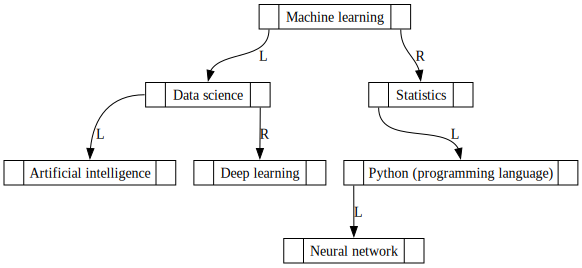

In [ ]:
from src.bst import visualize_bst
visualize_bst(bst)

## 2. Stack and Queue give DFS and BFS order

The same logic as `ThingContainer` + `NodeProcessor` code from homework, now operating over Wikipedia page titles.

In [12]:
print("=== DFS (Stack / LIFO) ===")
dfs = NodeProcessor(IterAlgorithm.DEPTH_FIRST)
print(f"Container type: {type(dfs.node_container).__name__}")
dfs.iterate_over(bst)

=== DFS (Stack / LIFO) ===
Container type: Stack
Machine learning
Statistics
Python (programming language)
Neural network
Data science
Deep learning
Artificial intelligence


In [13]:
print("=== BFS (Queue / FIFO) ===")
bfs = NodeProcessor(IterAlgorithm.BREADTH_FIRST)
print(f"Container type: {type(bfs.node_container).__name__}")
bfs.iterate_over(bst)

=== BFS (Queue / FIFO) ===
Container type: Queue
Machine learning
Data science
Statistics
Artificial intelligence
Deep learning
Python (programming language)
Neural network


## 3. The Stack and Queue are the same objects BFSFrontier and DFSFrontier use
- `frontier.py`: the method `BFSFrontier` and `DFSFrontier wraps queue and stck from `bst.py` and expose the frontier interface's add/pop/is_empty strategy. 

In [14]:
from src.frontier import BFSFrontier, DFSFrontier

# Peek inside a BFSFrontier to confirm it holds a Queue
bfs_frontier = BFSFrontier()
dfs_frontier = DFSFrontier()

print(f"BFSFrontier._container type : {type(bfs_frontier._container).__name__}")
print(f"DFSFrontier._container type : {type(dfs_frontier._container).__name__}")

# Demonstrate the interface equivalence
print("\n--- Queue (bst.py interface) ---")
q = Queue()
for item in ["A", "B", "C"]:
    q.put_new_thing_in(item)
print("FIFO out:", [q.take_existing_thing_out() for _ in range(3)])

print("\n--- BFSFrontier (frontier.py interface) ---")
f = BFSFrontier()
for item in ["A", "B", "C"]:
    f.add(item)
print("FIFO out:", [f.pop() for _ in range(3)])

BFSFrontier._container type : Queue
DFSFrontier._container type : Stack

--- Queue (bst.py interface) ---
FIFO out: ['A', 'B', 'C']

--- BFSFrontier (frontier.py interface) ---
FIFO out: ['A', 'B', 'C']


## 4. NodeProcessor loop vs WikiExplorer loop

The loop from `NodeProcessor.iterate_over()` next to the equivalent loop from `WikiExplorer.explore()`.  
The structure is **identical**.

```python
# NodeProcessor.iterate_over(tree)          # WikiExplorer.explore(start)
# ─────────────────────────────────────      # ──────────────────────────────────────
cur_node = tree.root                         node = WikiNode(start)
container.put_new_thing_in(cur_node)         frontier.add(node)

while not container.is_empty():             while not frontier.is_empty():
    cur_node = container.take_...()              node = frontier.pop()

    if cur_node.has_left_child():                links = scraper.get_links(node.title)
        container.put_new_thing_in(left)         for link in links:
    if cur_node.has_right_child():                   frontier.add(WikiNode(link))
        container.put_new_thing_in(right)

    print(cur_node.content)                      graph.mark_visited(node.title)
```

**BST children** (left, right) become **Wikipedia links** (any number of them).  
**Printing** becomes **recording the page in the graph**.  
Everything else is exactly the same algorithm.

In [15]:
target = WikiPage("Statistics")
steps = bst.find_item_steps(target)
print(f"Steps to find '{target}' in BST of {len(bst)} nodes: {steps}")
print(f"log2({len(bst)}) ≈ {len(bst).bit_length() - 1} — BST is at most this deep when balanced")

Steps to find 'Statistics' in BST of 7 nodes: 2
log2(7) ≈ 2 — BST is at most this deep when balanced


## Summary

| Concept | Course homework | This project |
|---|---|---|
| Node | `BSTNode` (content + left + right) | `WikiNode` (title + parent + depth) |
| Container | `ThingContainer` (abstract) | `Frontier` (abstract) |
| LIFO container | `Stack` | `DFSFrontier` wrapping `Stack` |
| FIFO container | `Queue` | `BFSFrontier` wrapping `Queue` |
| Traversal engine | `NodeProcessor` | `WikiExplorer` |
| "Children" of a node | `node.left`, `node.right` | Wikipedia links from page |
| Visited tracking | not needed (BST has no cycles) | `visited` set — O(1) lookup |
| Data structure for lookup | BST — O(log n) | Python set — O(1) |

Open `01_bfs_exploration.ipynb` next to see the Wikipedia explorer in action.